# Ridge Regression

For the purposes we are going to use Housing dataset, where we need to learn the parameters for the training dataset and then make a prediction on the test dataset

Here, we are just using the features as-is and not doing any feature engineering.

Closed Form solution for weights for Multiple Linear Regression is $(X^{T}X)^{-1}X^{T}Y$.

Closed Form solution for weights for Ridge Linear Regression is $(X^{T}X+λI)^{-1}X^{T}Y$.

For LASSO Linear Regression, there is NO closed form solution available.


## Implementation from Scratch

In [ ]:
import pandas as pd
import numpy as np

In [ ]:
df_train = pd.read_csv('/content/kc_house_train_data.csv')
df_test = pd.read_csv('/content/kc_house_test_data.csv')

In [ ]:
df_train

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,7129300520,20141013T000000,221900.0,3,1.00,1180,5650,1.0,0,0,...,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,6414100192,20141209T000000,538000.0,3,2.25,2570,7242,2.0,0,0,...,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,5631500400,20150225T000000,180000.0,2,1.00,770,10000,1.0,0,0,...,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
3,2487200875,20141209T000000,604000.0,4,3.00,1960,5000,1.0,0,0,...,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
4,1954400510,20150218T000000,510000.0,3,2.00,1680,8080,1.0,0,0,...,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17379,7936000429,20150326T000000,1007500.0,4,3.50,3510,7200,2.0,0,0,...,9,2600,910,2009,0,98136,47.5537,-122.398,2050,6200
17380,2997800021,20150219T000000,475000.0,3,2.50,1310,1294,2.0,0,0,...,8,1180,130,2008,0,98116,47.5773,-122.409,1330,1265
17381,263000018,20140521T000000,360000.0,3,2.50,1530,1131,3.0,0,0,...,8,1530,0,2009,0,98103,47.6993,-122.346,1530,1509
17382,291310100,20150116T000000,400000.0,3,2.50,1600,2388,2.0,0,0,...,8,1600,0,2004,0,98027,47.5345,-122.069,1410,1287


In [ ]:
# Select necessary columns from training and test datasets

df_train = df_train[['price','bedrooms','bathrooms','sqft_living','sqft_lot','floors','waterfront','view','condition','grade','sqft_above','sqft_basement','sqft_living15','sqft_lot15']]
df_test = df_test[['price','bedrooms','bathrooms','sqft_living','sqft_lot','floors','waterfront','view','condition','grade','sqft_above','sqft_basement','sqft_living15','sqft_lot15']]

In [ ]:
# Separate the Target variable from the training dataset
Y = np.array(df_train['price'])

In [ ]:
X = df_train.drop(['price'], axis=1)
H = np.array(X)

# Add a vector of 1s to the numpy array to represent the 1st feature
ones = np.ones(len(H))
H = np.column_stack((ones,H))

In [ ]:
# Calculate the parameter weights using the Closed Form solution of multiple linear regression
w = np.dot(np.linalg.pinv(np.dot(np.transpose(H),H)),np.dot(np.transpose(H),Y))

In [ ]:
w

array([-6.91987375e+05, -3.93524052e+04, -1.52851588e+04,  1.37689680e+02,
        7.99601476e-02, -6.02198592e+03,  6.09498294e+05,  5.62440119e+04,
        5.36268725e+04,  1.03070360e+05,  5.27614787e+01,  8.53259146e+01,
        9.50017959e+00, -8.07448536e-01])

In [ ]:
# Now we have the parameter weights and this can be used to make predictions on unseen data.
X_test = df_test.drop(['price'], axis=1)
H = np.array(X_test)
ones = np.ones(len(H))
H = np.column_stack((ones,H))
prediction = np.dot(H,w)

In [ ]:
prediction

array([382231.87109809, 960868.26041688, 368941.82906796, ...,
       688355.70221963, 537768.31648242, 290610.87328001])

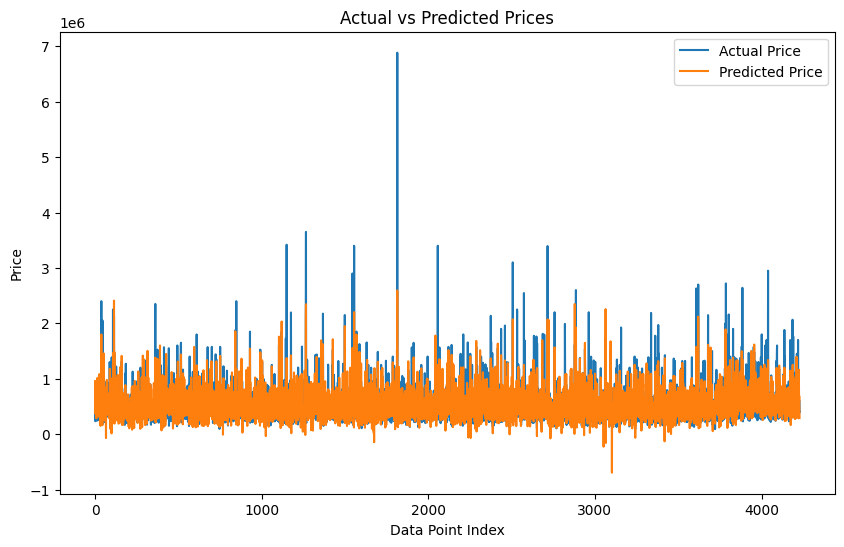

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(df_test['price'], label='Actual Price')
plt.plot(prediction, label='Predicted Price')
plt.xlabel("Data Point Index")
plt.ylabel("Price")
plt.title("Actual vs Predicted Prices")
plt.legend()
plt.show()

## Using scikit learn

In [ ]:
# Seperate the features from the training and testing dataset
X_train = np.array(df_train.drop(['price'], axis=1))
X_test = np.array(df_test.drop(['price'], axis=1))

In [ ]:
# Separate the Target variable from the training and testing dataset
Y_train = np.array(df_train['price'])
Y_test = np.array(df_test['price'])

In [ ]:
from sklearn.linear_model import LinearRegression

In [ ]:
lr = LinearRegression()
lr.fit(X_train, Y_train)
y_pred = lr.predict(X_test)

In [ ]:
from sklearn.metrics import mean_squared_error as mse
mse(Y_test, y_pred)

51580148709.2037

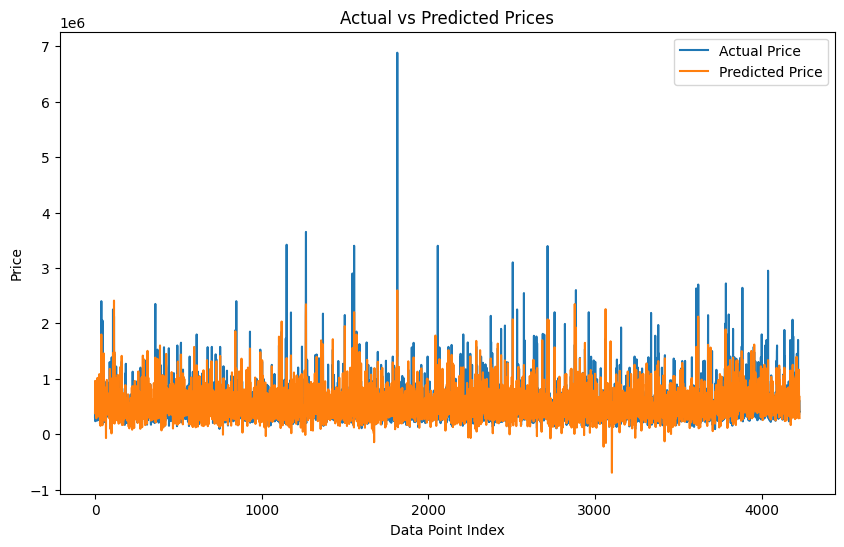

In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(Y_test, label='Actual Price')
plt.plot(y_pred, label='Predicted Price')
plt.xlabel("Data Point Index")
plt.ylabel("Price")
plt.title("Actual vs Predicted Prices")
plt.legend()
plt.show()

In [ ]:
from sklearn.metrics import r2_score
r2 = r2_score(Y_test, y_pred)
print("R-squared (using sklearn):", r2)

R-squared (using sklearn): 0.5938764921574518


Ridge Regression ($L_2$ Regularization)

In [ ]:
from sklearn.linear_model import Ridge

In [ ]:
ridge = Ridge(alpha=0.02)
ridge.fit(X_train, Y_train)
y_pred_ridge = ridge.predict(X_test)

In [ ]:
from sklearn.metrics import r2_score
r2 = r2_score(Y_test, y_pred_ridge)
print("R-squared (using sklearn):", r2)

R-squared (using sklearn): 0.5938778303033301


Lasso Regression ($L_1$ Regularization)

In [ ]:
from sklearn.linear_model import Lasso

In [ ]:
lasso = Lasso(alpha=0.1, max_iter=100000)
lasso.fit(X_train, Y_train)
y_pred_lasso = lasso.predict(X_test)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.207e+14, tolerance: 2.376e+11
  model = cd_fast.enet_coordinate_descent(


In [ ]:
from sklearn.metrics import r2_score
r2 = r2_score(Y_test, y_pred_lasso)
print("R-squared (using sklearn):", r2)

R-squared (using sklearn): 0.5938767358735944
